In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(data.table)
library(ggplot2)
library(ggsci)
library(scales)
library(ggrepel)

In [2]:
# mapping bridge
bridge <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/220524_hgnc_ensg_enst_chr_pos.txt.gz")
hgnc_to_ensembl <- bridge$ensembl_gene_id
names(hgnc_to_ensembl) <- bridge$hgnc_symbol
ensembl_to_hgnc <- bridge$hgnc_symbol
names(ensembl_to_hgnc) <- bridge$ensembl_gene_id
ensembl_to_pos <- (bridge$end_position + bridge$end_position) / 2
names(ensembl_to_pos) <- bridge$ensembl_gene_id

In [3]:
plof_csqs = c("transcript_ablation", "splice_acceptor_variant",
             "splice_donor_variant", "stop_gained", "frameshift_variant")

missense_csqs = c("stop_lost", "start_lost", "transcript_amplification",
                 "inframe_insertion", "inframe_deletion", "missense_variant")

synonymous_csqs = c("stop_retained_variant", "synonymous_variant")

other_csqs = c("mature_miRNA_variant", "5_prime_UTR_variant",
              "3_prime_UTR_variant", "non_coding_transcript_exon_variant", "intron_variant",
              "NMD_transcript_variant", "non_coding_transcript_variant", "upstream_gene_variant",
              "downstream_gene_variant", "TFBS_ablation", "TFBS_amplification", "TF_binding_site_variant",
              "regulatory_region_ablation", "regulatory_region_amplification", "feature_elongation",
              "regulatory_region_variant", "feature_truncation", "intergenic_variant")


In [4]:
#pattern = "maf0to5e-2_pLoF_damaging_missense_all.tsv.gz"

In [117]:
# helper functions
fread_kos <- function(paths, split = NULL){
    dt <- do.call(rbind,lapply(paths, fread))
    dt$n_variants <- stringi::stri_count(dt$varid, fixed = split) + 1
    return(dt)
}
# sub hail list
gsub_hail_list <- function(x){return(gsub('(\\[)|(\\])|(\\")',"", gsub(",",";",x)))}
# apply through hail
happly <- function(x, FUN, split = ";"){return(FUN(unlist(strsplit(x, split = split))))}
# a function to calculate probability of expected KO for a sample
calc_expt <- function(n){return(1 - 2*(0.5)^(n))}
# get observed expected matrix by gene
get_obs_expt <- function(d){
    obs <- aggregate(pKO ~ gene_id, data = d, FUN = sum) 
    expt <- aggregate(p_expt ~ gene_id, data = d, FUN = sum) 
    colnames(obs) <- c("gene_id","obs")
    colnames(expt) <- c("gene_id","expt")
    mrg <- merge(obs, expt, by = "gene_id", all = TRUE)
    mrg$obs[is.na(mrg$obs)] <- 0
    mrg <- mrg[mrg$expt > 0,]
    mrg$ratio <- mrg$obs / mrg$expt
    return(mrg)
}

In [151]:
paths_syn <- list.files("data/knockouts/old/alt", pattern = "chr[0-9]+_synonymous_all", full.names = TRUE)
paths_plof <- list.files("data/knockouts/old/alt", pattern = "chr[0-9]+_pLoF_all", full.names = TRUE)
paths_dm <- list.files("data/knockouts/old/alt", pattern = "chr[0-9]+_damaging_missense_all", full.names = TRUE)
paths_pdm <- list.files("data/knockouts/alt/pp90/combined", pattern = "chr[0-9]+_pLoF_damaging_missense_all", full.names = TRUE)

In [152]:
#paths_plof <- paths_plof[1:2]
#paths_syn <- paths_syn[1:2]
#paths_dm <- paths_dm[1:2]
paths_pdm <- paths_pdm[1:22]

In [153]:
#d_plof <- fread_kos(paths_plof)
#d_syn <- fread_kos(paths_syn)
#d_mis <- fread_kos(paths_dm)
d_pdm <- fread_kos(paths_pdm, split = ';')

In [154]:
table(d_pdm$n_variants)


      1       2       3       4       5       6 
7420696  109411    4397     341      14      13 

In [156]:
get_obs_expt_chet <- function(dt){
    # at least two variants required
    dt <- dt[dt$n > 0,]
    # set expt and obs variables
    dt$obs <- dt$pKO
    dt$expt <- calc_expt(dt$n_variants)
    # count by gene
    d_obs <- aggregate(obs ~ gene_id, data = dt, FUN = sum)
    d_expt <- aggregate(expt ~ gene_id, data = dt, FUN = sum)
    d_out <- merge(d_expt, d_obs, all = TRUE)
    d_out <- d_out[d_out$expt > 0,]
    return(d_out)
}


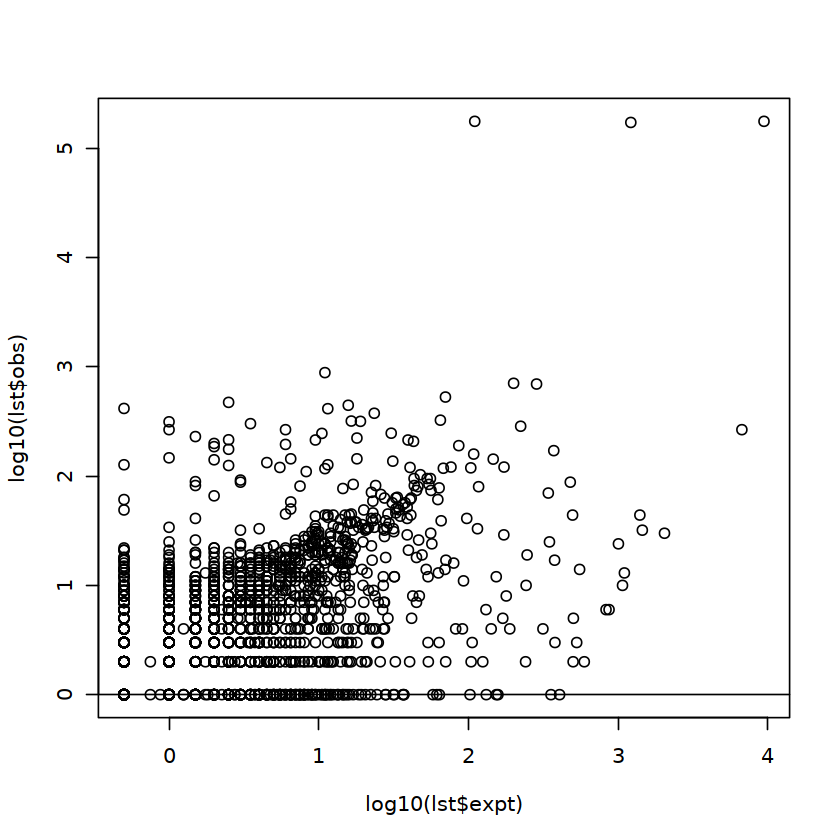

In [161]:
#lst <- get_obs_expt_chet(d_pdm)
plot(log10(lst$expt), log10(lst$obs))
abline(a = log10(1),b = 0)

Warning message in int_abline(a = a, b = b, h = h, v = v, untf = untf, ...):
""linetype" is not a graphical parameter"


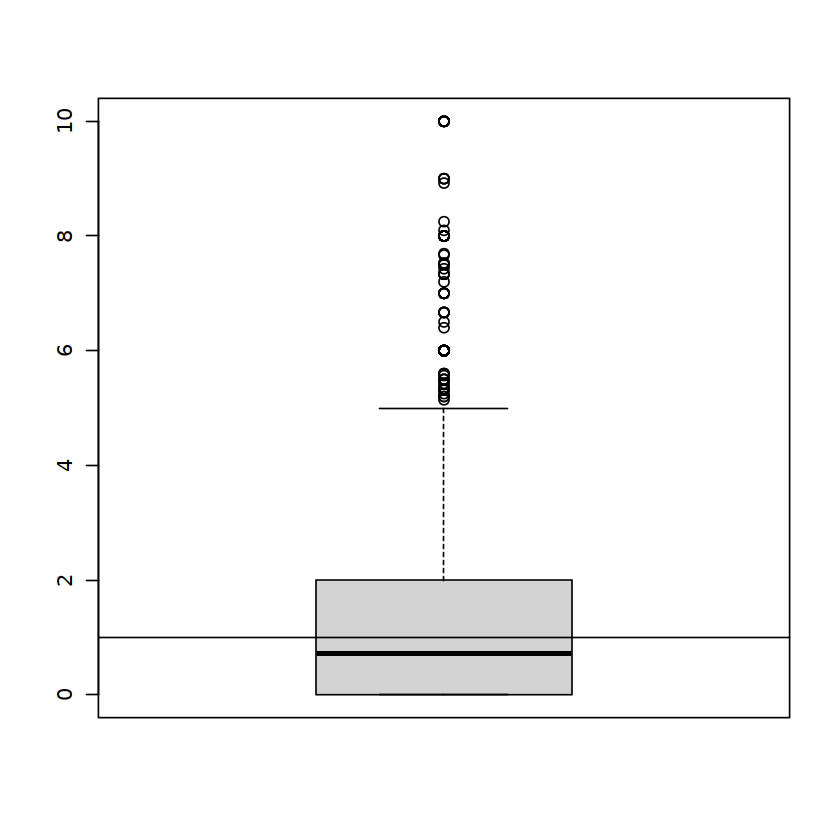

In [174]:
boxplot(lst$obs/lst$expt, ylim = c(0,10))
abline(h = 1, linetype = 'dashed')

In [62]:
expt

gene_id,n,expt
<chr>,<list>,<list>
ENSG00000006611,"0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5",14.5
ENSG00000023191,"0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.50",8.75
ENSG00000065618,"0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5",6.5
ENSG00000067057,"0.5, 0.5",1
ENSG00000107554,"0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5",3.5
ENSG00000110031,"0.5, 0.5, 0.5, 0.5, 0.5, 0.5",3
ENSG00000121236,"0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.75, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.75, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50, 0.50",150.5
ENSG00000122359,"0.5, 0.5",1
ENSG00000122367,"0.5, 0.5, 0.5",1.5


In [46]:
get_obs_expt <- function(d){
    obs <- aggregate(pKO ~ gene_id, data = d, FUN = sum) 
    expt <- aggregate(p_expt ~ gene_id, data = d, FUN = sum) 
    colnames(obs) <- c("gene_id","obs")
    colnames(expt) <- c("gene_id","expt")
    mrg <- merge(obs, expt, by = "gene_id", all = TRUE)
    mrg$obs[is.na(mrg$obs)] <- 0
    mrg <- mrg[mrg$expt > 0,]
    mrg$ratio <- mrg$obs / mrg$expt
    return(mrg)
}

gene_id,s,gts,varid,hom_alt_n,phased.a1,phased.a2,unphased.n,pKO,knockout,n
<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<int>
ENSG00000012779,1017198,1|0,chr10:45374384:GCA:G,0,1,0,0,0,Heterozygote,0
ENSG00000012779,1077109,1|0,chr10:45444259:G:A,0,1,0,0,0,Heterozygote,0
ENSG00000012779,1386375,1|0,chr10:45444259:G:A,0,1,0,0,0,Heterozygote,0
ENSG00000012779,1417267,0|1,chr10:45444259:G:A,0,0,1,0,0,Heterozygote,0
ENSG00000012779,1643625,1|0,chr10:45440634:G:A,0,1,0,0,0,Heterozygote,0
ENSG00000012779,1760950,0|1,chr10:45445600:CA:C,0,0,1,0,0,Heterozygote,0
ENSG00000012779,1854845,0|1,chr10:45374384:GCA:G,0,0,1,0,0,Heterozygote,0
ENSG00000012779,1894903,1|0,chr10:45445571:C:T,0,1,0,0,0,Heterozygote,0
ENSG00000012779,2246529,0|1,chr10:45440634:G:A,0,0,1,0,0,Heterozygote,0


In [15]:
d_plof$varid <- gsub_hail_list(d_plof$varid)
d_syn$varid <- gsub_hail_list(d_syn$varid)
d_mis$varid <- gsub_hail_list(d_mis$varid)

In [17]:
d_plof$p_expt <- calc_expected(d_plof$varid)
#d_syn$p_expt <- calc_expected(d_syn$varid)
d_mis$p_expt <- calc_expected(d_mis$varid)

In [ ]:
oe_plof <- get_obs_expt(d_plof)[,c("gene_id","ratio")]
oe_mis <- get_obs_expt(d_mis)[,c("gene_id","ratio")]
oe_syn <- get_obs_expt(d_syn)[,c("gene_id","ratio")]
colnames(oe_plof)[2] <- "plof_ratio"
colnames(oe_mis)[2] <- "mis_ratio"
colnames(oe_syn)[2] <- "syn_ratio"

In [195]:
mrg <- merge(merge(oe_plof, oe_mis, all = TRUE), oe_syn, all = TRUE)
mrg[is.na(mrg)] <- 0
melted_mrg <- melt(mrg)
melted_mrg <- melted_mrg[is.finite(melted_mrg$value),]


Warning message in melt(mrg):
"The melt generic in data.table has been passed a data.frame and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is deprecated, and this redirection is now deprecated as well. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace like reshape2::melt(mrg). In the next version, this warning will become an error."
Using gene_id as id variables



Warning message:
"Removed 18 rows containing non-finite values (stat_boxplot)."


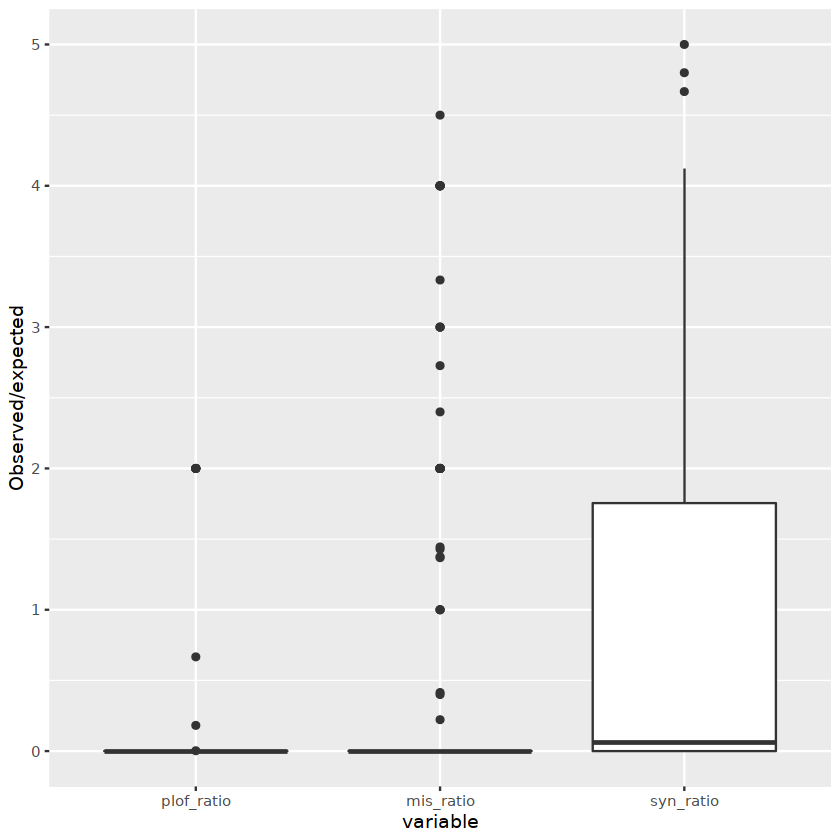

In [197]:
ggplot(melted_mrg, aes(y=value, x=variable)) +
    geom_boxplot() +
    ylab("Observed/expected") +
    ylim(0,5)

In [132]:
#samples_with_many_hets <- d_syn[((d_syn$phased.a1 + d_syn$phased.a2) > 1) & (d_syn$hom_alt_n == 0),]
#samples_with_kos <- d_syn[(d_syn$pKO == 1) & (d_syn$hom_alt_n == 0),]

#samples_with_many_hets <- d_mis[((d_mis$phased.a1 + d_mis$phased.a2) > 1) & (d_mis$hom_alt_n == 0),]
#samples_with_kos <- d_mis[(d_mis$pKO == 1) & (d_mis$hom_alt_n == 0),]

# expected must be the number of samples that carry at least two variants, i.e. 



# count observed as the number of samples that has carries knockouts
obs_all <- data.table(table(samples_with_many_hets$gene_id))
obs <- data.table(table(samples_with_kos$gene_id))
expt <- aggregate(p ~ gene_id, data = samples_with_many_hets, FUN = sum) 
colnames(obs) <- c("gene_id","obs")
colnames(expt) <- c("gene_id","expt")
mrg <- merge(obs, expt, by = "gene_id", all = TRUE)
mrg$obs[is.na(mrg$obs)] <- 0


Warning message in is.na(x):
"is.na() applied to non-(list or vector) of type 'language'"
Warning message in is.na(x):
"is.na() applied to non-(list or vector) of type 'language'"


ERROR: Error in sort.int(x, na.last = na.last, decreasing = decreasing, ...): 'x' must be atomic


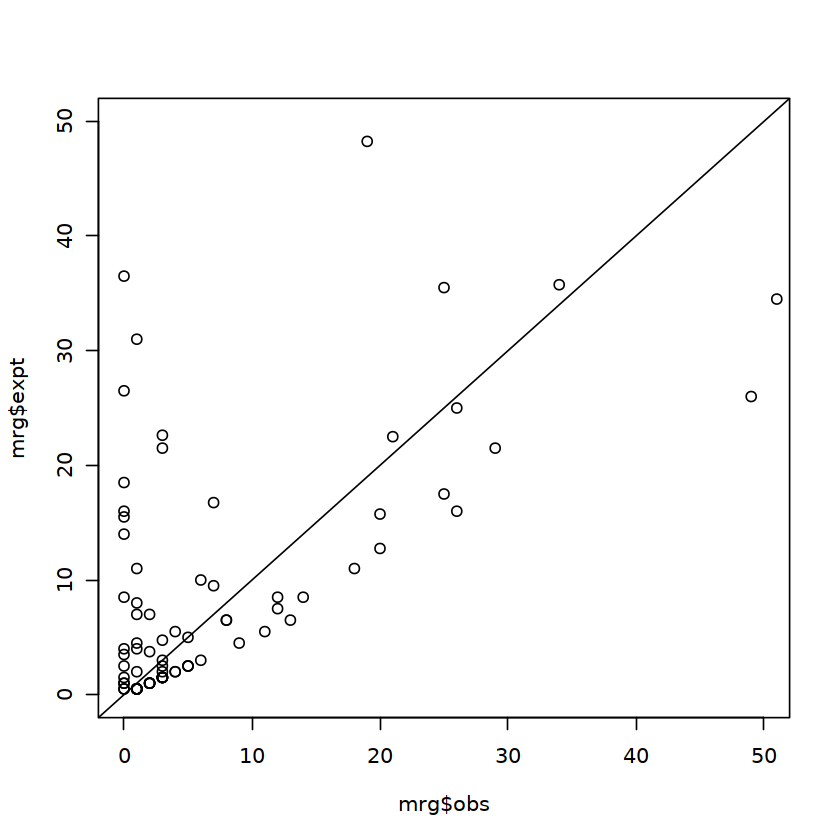

In [135]:
plot(mrg$obs, mrg$expt, xlim = c(0, 50), ylim=c(0, 50))
abline(a=0, b=1)
plot(density(mrg$expt / mrg$obs), xlim = c(0,10))
abline(v=1, lty = 2)

In [5]:
#knockouts <- list.files("data/knockouts/alt/", pattern = pattern)

In [6]:
print(length(knockouts))

[1] 22


In [7]:
d <- fread( paste0("data/mt/vep/worst_csq_by_gene_canonical/ukb_eur_wes_union_calls_200k_chr21.tsv.gz"))


# Aggregation of variants for counts

In [98]:
# this aggregation is now being accomplished in a seperate script
dt1 <- fread("data/post_hoc/results/ukb_wes_union_calls_200k_variants.pp90_prefilter.txt.gz")
dt2 <- fread("data/post_hoc/results/ukb_wes_union_calls_200k_variants.pp90_postfilter.txt.gz")
stopifnot((dt1$variant_category == dt2$variant_category) & (dt1$consequence_category == dt2$consequence_category))

In [122]:
dt2_filter <- dt2[,c("n_total","n_singletons","pct_singletons")]
colnames(dt2_filter) <- paste0("filter_",colnames(dt2_filter))
combi <- cbind(dt1, dt2_filter)
combi

super_category,consequence_category,variant_category,n_total,n_singletons,pct_singletons,filter_n_total,filter_n_singletons,filter_pct_singletons
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<dbl>
PTV,damaging_missense,frameshift_variant,18513,8841,47.8,18304,8744,47.8
PTV,pLoF,frameshift_variant,129686,72273,55.7,127615,71145,55.7
PTV,damaging_missense,splice_acceptor_variant,941,503,53.5,895,474,53.0
PTV,pLoF,splice_acceptor_variant,26551,15269,57.5,26187,15071,57.6
PTV,damaging_missense,splice_donor_variant,502,251,50.0,467,231,49.5
PTV,pLoF,splice_donor_variant,34729,18865,54.3,34266,18616,54.3
PTV,damaging_missense,stop_gained,12772,5693,44.6,12610,5630,44.6
PTV,pLoF,stop_gained,103567,53166,51.3,101913,52351,51.4
PTV,damaging_missense,,32728,15288,46.7,32276,15079,46.7


In [203]:
levels <- c("non_coding","synonymous", 'other_missense', 'damaging_missense', 'LC', 'pLoF')

In [214]:
dt_subset <- combi[combi$variant_category == "" & combi$consequence_category != "",]
dt_subset$consequence_category <- factor(as.character(dt_subset$consequence_category), levels = levels)
#dt_subset$consequence_category[1] <- "LC"

In [215]:
dt_combi <- rbind(
    data.frame(
        super_category = dt_subset$super_category,
        variant_category = dt_subset$variant_category,
        consequence_category = dt_subset$consequence_category,
        is_singleton = FALSE,
        n = dt_subset$filter_n_total
    ),
    data.frame(
        super_category = dt_subset$super_category,
        variant_category = dt_subset$variant_category,
        consequence_category = dt_subset$consequence_category,
        is_singleton = TRUE,
        n = dt_subset$filter_n_singletons
    )
)

In [229]:
dt_combi$consequence_category <- factor(as.character(dt_combi$consequence_category), levels = levels)
dt_combi <- dt_combi[dt_combi$consequence_category %in% c("pLoF","damaging_missense"),]

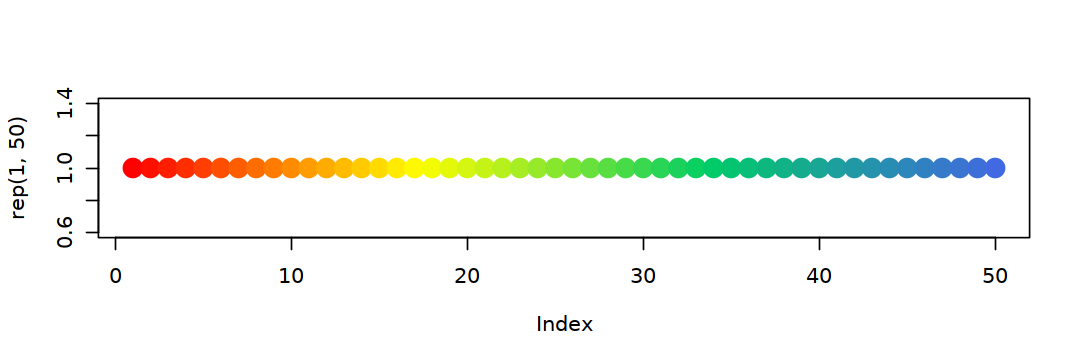

In [220]:
options(repr.plot.width=9, repr.plot.height=3)
colfunc<-colorRampPalette(c("red","yellow","springgreen3","royalblue"))
plot(rep(1,50),col=(colfunc(50)), pch=19,cex=2)
colors <- colfunc(50)

In [221]:
my_colors <- c(colors[48], colors[35], colors[16], colors[8], colors[2], colors[2])
names(my_colors) <- levels
fill_scale <- scale_fill_manual(name = "consequence_category", values = my_colors)
color_scale <- scale_color_manual(name = "consequence_category", values = my_colors)

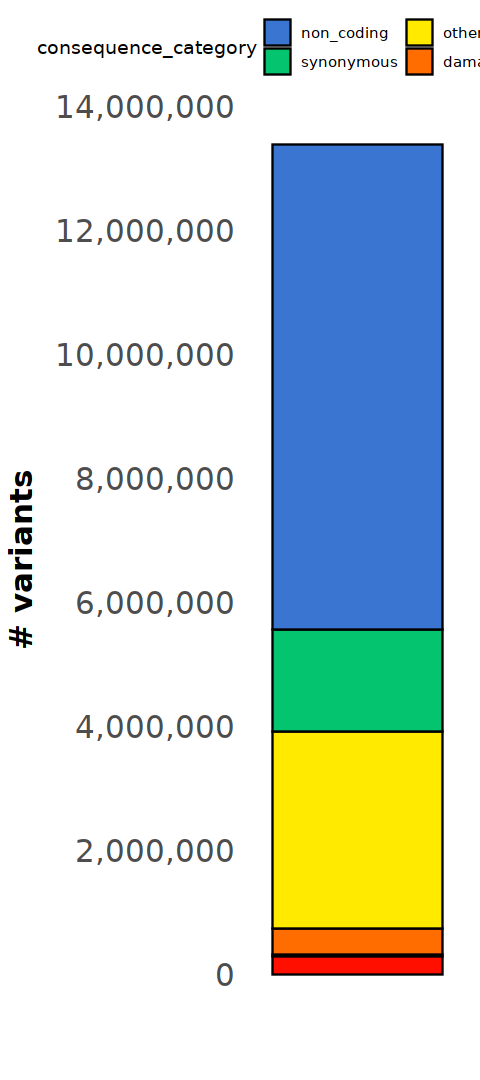

In [222]:
options(repr.plot.width=4, repr.plot.height=9)
p1 <- ggplot(dt_subset, aes(x="", y=n_total, fill=consequence_category)) +
    #scale_y_continuous(trans='log10') +
    geom_bar(stat="identity", color = 'black') +
    #xlab("Consequence Category") +
    xlab("") +
    ylab("# variants") +
    fill_scale +
    scale_y_continuous(
        breaks=scales::pretty_breaks(n=10), 
        labels = scales::comma #function(x) format(x, scientific = FALSE)
        ) +
    theme_minimal() +
    theme(
        legend.position = "top",
        strip.text = element_text(size=18),
        axis.text=element_text(size=18),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 90, vjust = 1, hjust=1),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    ) 
print(p1)

,super_category,variant_category,consequence_category,is_singleton,n
,<chr>,<chr>,<fct>,<lgl>,<int>
1,PTV,,damaging_missense,FALSE,32276
2,PTV,,pLoF,FALSE,289981
3,Missense,,damaging_missense,FALSE,412528
7,PTV,,damaging_missense,TRUE,15079
8,PTV,,pLoF,TRUE,157183
9,Missense,,damaging_missense,TRUE,200464


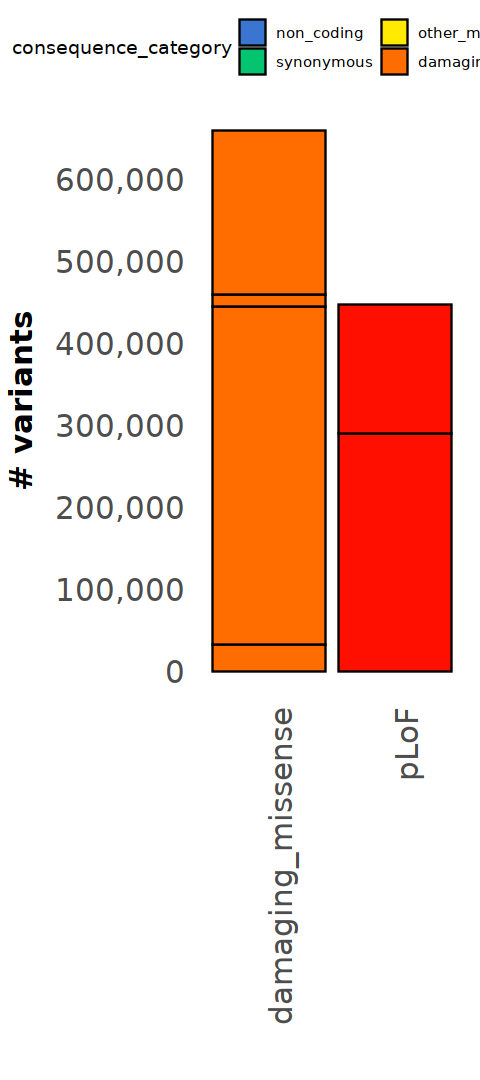

In [232]:
options(repr.plot.width=4, repr.plot.height=9)
dt_combi
p1 <- ggplot(dt_combi, aes(x=consequence_category, y=n, fill=consequence_category)) +
    #scale_y_continuous(trans='log10') +
    geom_bar(stat="identity", color = 'black') +
    #xlab("Consequence Category") +
    xlab("") +
    ylab("# variants") +
    fill_scale +
    scale_y_continuous(
        breaks=scales::pretty_breaks(n=10), 
        labels = scales::comma #function(x) format(x, scientific = FALSE)
        ) +
    theme_minimal() +
    theme(
        legend.position = "top",
        strip.text = element_text(size=18),
        axis.text=element_text(size=18),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 90, vjust = 1, hjust=1),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    ) 
print(p1)

In [ ]:
options(repr.plot.width=4, repr.plot.height=9)
p1 <- ggplot(dt_subset, aes(x="", y=n_total, fill=consequence_category)) +
    #scale_y_continuous(trans='log10') +
    geom_bar(stat="identity", color = 'black') +
    #xlab("Consequence Category") +
    xlab("") +
    ylab("# variants") +
    fill_scale +
    scale_y_continuous(
        breaks=scales::pretty_breaks(n=10), 
        labels = scales::comma #function(x) format(x, scientific = FALSE)
        ) +
    theme_minimal() +
    theme(
        legend.position = "top",
        strip.text = element_text(size=18),
        axis.text=element_text(size=18),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 90, vjust = 1, hjust=1),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    ) 
print(p1)

In [16]:
dt_subset <- outdt[outdt$super_category %in% c("PTV","Missense") & outdt$variant_category != " ",]
dt_combi <- rbind(
    data.frame(
        super_category = dt_subset$super_category,
        variant_category = dt_subset$variant_category,
        consequence_category = dt_subset$consequence_category,
        is_singleton = FALSE,
        n = dt_subset$n_total
    ),
    data.frame(
        super_category = dt_subset$super_category,
        variant_category = dt_subset$variant_category,
        consequence_category = dt_subset$consequence_category,
        is_singleton = TRUE,
        n = dt_subset$n_singletons
    )
)


In [17]:
dt_combi$consequence_category <- factor(
    dt_combi$consequence_category,
    levels = c("pLoF", "LC", "other_missense","damaging_missense")
)

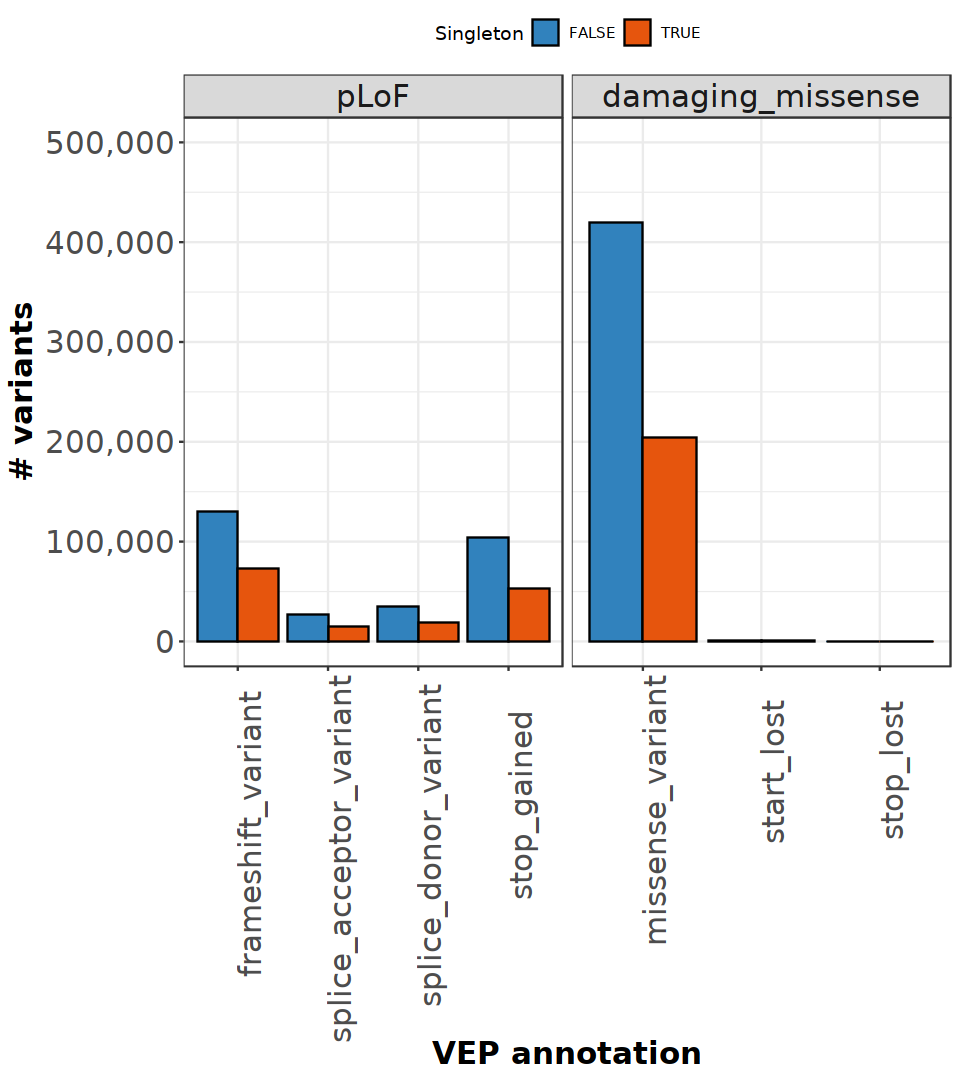

In [18]:
options(repr.plot.width=8, repr.plot.height=9)
p2 <- ggplot(
    #dt_combi,
    dt_combi[dt_combi$consequence_category %in% c("pLoF","damaging_missense"),], 
             aes(x=variant_category, y=n, fill=is_singleton)) +
    #scale_y_continuous(trans='log10') +
    geom_bar(stat="identity", position = position_dodge(), color = 'black') +
    xlab("VEP annotation") +
    ylab("# variants") +
    labs(fill = "Singleton") +
    scale_fill_d3(palette = "category20c") +
    scale_y_continuous(
        breaks=scales::pretty_breaks(n=5), 
        labels = scales::comma #function(x) format(x, scientific = FALSE)
        ) +
    theme_bw() +
    theme(
        legend.position = "top",
        strip.text = element_text(size=18),
        axis.text=element_text(size=18),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 90, vjust = 1, hjust=0.8)
    ) +
    coord_cartesian(ylim=c(0,500000)) + 
    facet_wrap(~consequence_category, scales = "free_x")
p2


In [19]:
dt

super_category,consequence_category,variant_category,n_total,n_singletons,pct_singletons
<chr>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
Missense,other_missense,inframe_deletion,41887,17767,42.4
Missense,other_missense,inframe_insertion,17517,7118,40.6
Missense,damaging_missense,missense_variant,419791,204566,48.7
Missense,other_missense,missense_variant,3099923,1331516,43.0
Missense,damaging_missense,start_lost,1093,580,53.1
Missense,other_missense,start_lost,9294,4479,48.2
Missense,damaging_missense,stop_lost,1,1,100.0
Missense,other_missense,stop_lost,3415,1818,53.2
Non-coding,non_coding,3_prime_UTR_variant,347656,148227,42.6


In [570]:

lst <- do.call(rbind, lapply(1:22, function(chr){
    file <- paste0("data/knockouts/alt/pp90/combined/ukb_eur_wes_200k_chr",chr,"_damaging_missense_all.tsv.gz")
    d <- fread(file)
    return(d)
    }
))

In [574]:
table(lst$knockout)


Compound heterozygote            Homozygote 
                 6736                  6593 

In [571]:
d <- as.data.frame(table(lst$varid))
head(d[rev(order(d$Freq)),])

integer(0)

# Aggregation of variants in Compound Hets

In [548]:
common_plofs <- c("chr3:44499299:TTC:T", "chr9:137245305:G:A", "chr1:171208951:C:T")
annotations <- c("damaging_missense") #, "pLoF", "pLoF_damaging_missense") # "other_missense"
categories <- c("chets","homs","cis")
autosomes <- 22 #c(18,13,15,21,22)

In [568]:
lst <- lapply(annotations, function(annotation){

    write(paste("Using category",annotation), stderr())
    d <- do.call(rbind, lapply(autosomes, function(chr){
        
        # load file
        file <- paste0("data/knockouts/alt/pp90/combined/ukb_eur_wes_200k_chr",chr,"_",annotation,"_all.tsv.gz")
        d <- fread(file)
        #print(head(d))
        
        # exclude common pLoFs 
        #keep <- (d$varid %in% common_plofs)
        #print(sum(keep))
        #d <- d[keep, with = FALSE]
        #print(head(d))
        
        # get booleans
        d$chr <- stringr::str_extract(d$varid, "chr[0-9]+")
        d$is_het <- d$knockout == "Heterozygote"
        d$is_cis <- d$knockout == "Compound heterozygote (cis)"
        d$is_hom <- grepl("Hom", d$knockout)
        d$is_chet <- d$knockout == "Compound heterozygote"

        # clean up columns
        d$hom_alt_n <- NULL
        d$phased.a1 <- NULL
        d$phased.a2 <- NULL
        d$unphased.n <- NULL
        d$pKO <- NULL
        
        # combine into value matrix
        vals <- data.frame(
            t(
            data.frame(
                homs = sum(d$is_hom),
                chets = sum(d$is_chet),
                cis = sum(d$is_cis)
                )
            )
        )
        
        # rename
        colnames(vals) <- "n"
        vals$category <- rownames(vals)
        rownames(vals) <- NULL
        
        # appened category
        vals$annotation <- annotation
        vals$chromosome <- chr
        return(vals)
    }))
    
    # aggregate category and annotation
    aggr <- aggregate(n~category+annotation, data = d, FUN = sum)
    aggr$proportion <- aggr$n / sum(aggr$n)
    return(aggr)
})

In [569]:
plotdf <- do.call(rbind, lst)
plotdf
#plotdf$category <- factor(plotdf$category, levels = categories)
#plotdf$annotation <- factor(plotdf$annotation, levels = annotations)

category,annotation,n,proportion
<chr>,<chr>,<int>,<dbl>
chets,damaging_missense,126,0.4051447
cis,damaging_missense,0,0.0000000
homs,damaging_missense,185,0.5948553


In [551]:
my_colors <- c("#65B8EF","#81A8C9", "#7BA98A")
names(my_colors) <- categories
fill_scale <- scale_fill_manual(name = "consequence_category", values = my_colors)
color_scale <- scale_color_manual(name = "consequence_category", values = my_colors)

In [552]:
plotdf

category,annotation,n,proportion
<fct>,<fct>,<int>,<dbl>
chets,damaging_missense,0,NaN
cis,damaging_missense,0,NaN
homs,damaging_missense,0,NaN


Warning message:
"Removed 3 rows containing missing values (position_stack)."


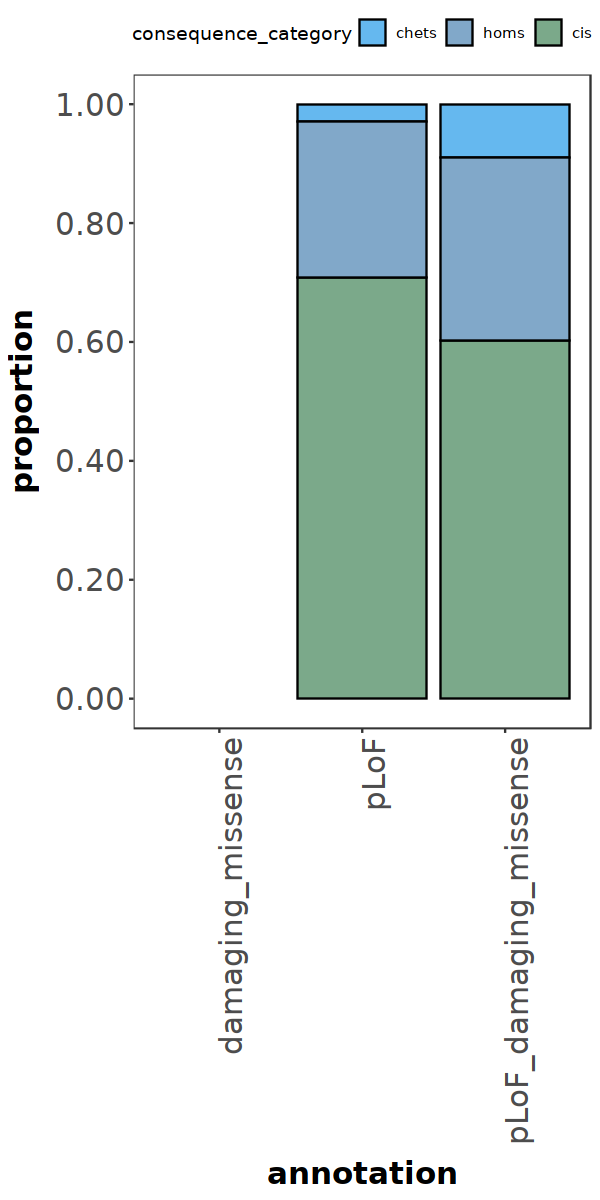

In [537]:
options(repr.plot.width=5, repr.plot.height=10)
ggplot(plotdf, aes(x=annotation,y=proportion, fill = category)) +
    geom_bar(stat="identity", color = "black") +
    scale_y_continuous(
        breaks=scales::pretty_breaks(n=5), 
        labels = scales::comma
    ) +
    fill_scale + 
    theme_bw() +
    theme(
        legend.position = "top",
        strip.text = element_text(size=18),
        axis.text=element_text(size=18),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 90, vjust = 1, hjust=1),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank()
    )

In [500]:
options(repr.plot.width=12, repr.plot.height=6)
set.seed(7)
genes <- unique(d$gene_id[d$pKO == 1])
d_genes <- d[d$gene_id %in% genes,]
d_genes <- as.data.table(table(d_genes$gene_id, d_genes$knockout))
d_genes <- dcast(V1 ~ V2, value.var = "N", data = d_genes)
colnames(d_genes) <-  c("gene_id",'chet_trans','chet_cis','het','hom', 'chet_unknown')#c("gene_id",'chet_trans','chet_cis','het','hom', 'chet_unknown')
d_genes$knockouts <- d_genes$chet_trans + d_genes$hom
#d_genes <- d_genes[d_genes$knockouts >= 2,]
d_genes <- d_genes[rev(order(d_genes$knockouts)),]
d_genes$hgnc_symbol <- ensembl_to_hgnc[d_genes$gene_id]

top_hom <- head(d_genes$hgnc_symbol[rev(order(d_genes$hom))], n = 2)
top_chet_trans <- head(d_genes$hgnc_symbol[rev(order(d_genes$chet_trans))], n = 7)

# select genes for plotting
selected_genes <- c(top_hom, top_chet_trans, "CFTR", "MUTYH", "FAAH", "MICA")
bool_selected <- d_genes$hgnc_symbol %in% selected_genes
d_genes$label <- ""
d_genes$label[bool_selected] <- d_genes$hgnc_symbol[bool_selected]

ggplot(d_genes, aes(x=hom, y=chet_trans, label = label)) + 
    geom_point() + 
    geom_label_repel(
        box.padding = 0.75, label.padding=0.15, point.padding = 1.5,
        color = 'grey30', segment.color = 'grey50', max.overlaps=Inf,
        size=5, segment.size=0.2, show.legend = FALSE, alpha = 0.9
    ) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab("Homozygous knockouts") +
    ylab("Compound heterozygos knockouts") +
    theme_bw() +
    theme(
        legend.position = "top",
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5)
    ) + coord_fixed()

ERROR: Error in (function (..., sorted = TRUE, unique = FALSE) : attempt to set an attribute on NULL


In [164]:
d_chet_trans <- d_genes[,c('gene_id',"chet_trans")]
colnames(d_chet_trans)[2] <- "N"
d_chet_trans$type <- "chet_trans"
d_chet_trans$rank <- rank(d_chet_trans$N)
d_chet_cis <- d_genes[,c('gene_id',"chet_cis")]
colnames(d_chet_cis)[2] <- "N"
d_chet_cis$type <- "chet_cis"
d_chet_cis$rank <- rank(d_chet_cis$N)
# homs
d_hom <- d_genes[,c('gene_id',"hom")]
colnames(d_hom)[2] <- "N"
d_hom$type <- "hom"
d_hom$rank <- rank(d_hom$N)
d_combined_type <- rbind(d_chet_trans, d_chet_cis, d_hom)

# select genes to plot
selected_genes <- c("CFTR", "MUTYH")
d_combined_type$hgnc_symbol <- ensembl_to_hgnc[d_combined_type$gene_id]
bool_selected <- d_combined_type$hgnc_symbol %in% selected_genes
d_combined_type$label <- ""
d_combined_type$label[bool_selected] <- d_combined_type$hgnc_symbol[bool_selected]

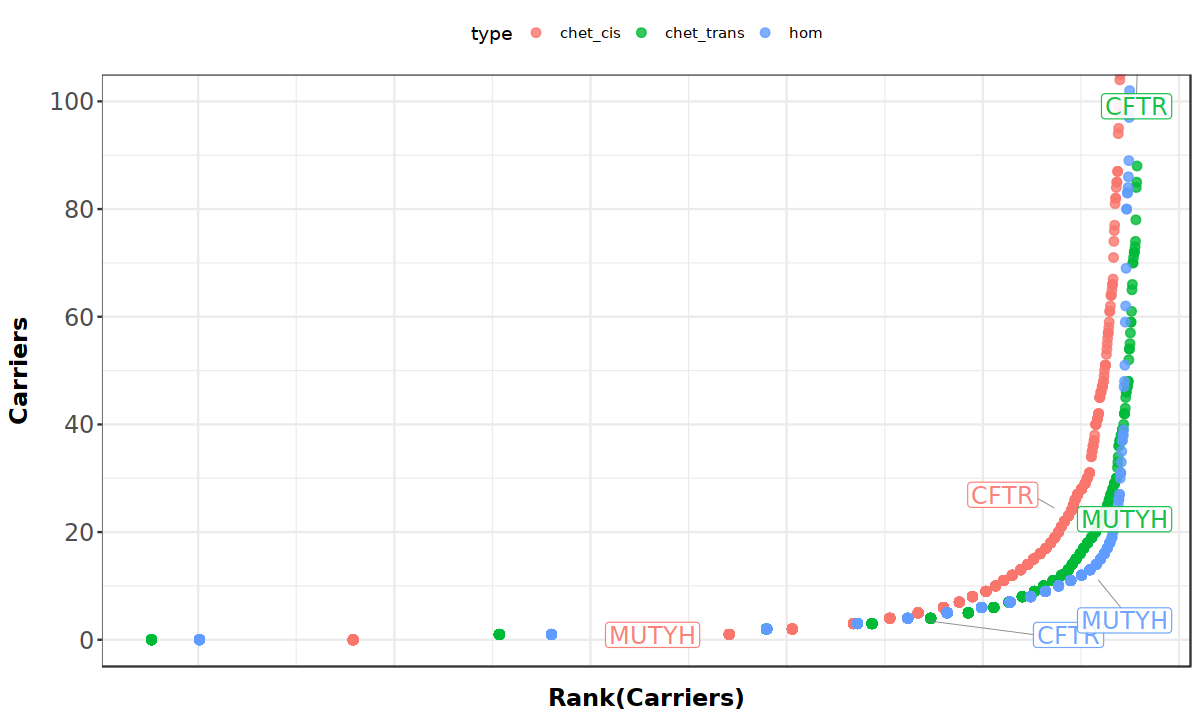

In [170]:
options(repr.plot.width=10, repr.plot.height=6)
ggplot(d_combined_type, aes(x=rank,y=N, color = type, label = label)) +
    geom_point(alpha = 0.8, size = 2) +
    geom_label_repel(
        box.padding = 0.80, label.padding=0.15, point.padding = 1.5,
        segment.color = 'grey50', max.overlaps=Inf,
        size=5, segment.size=0.2, show.legend = FALSE, alpha = 0.9
    ) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    xlab("Rank(Carriers)") +
    ylab("Carriers") +
    coord_cartesian(ylim=c(0, 100)) +
    theme_bw() +
    theme(
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank(),
        legend.position = "top",
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10))
    )

#### Correlations between counts

In [25]:
d_genes_test <- d_genes[d_genes$knockout >= 2]
cols <- c("het","hom","chet_trans","chet_cis",'chet_unknown')
M1 <- do.call(rbind, lapply(cols, function(c1){
    M2 <- do.call(cbind, lapply(cols, function(c2){
        
        
         test <- cor.test(d_genes_test[[c1]], d_genes_test[[c2]])
         return(as.numeric(test$estimate))
    }))
    colnames(M2) <- cols
    return(M2)         
}))
rownames(M1) <- cols
M1


,het,hom,chet_trans,chet_cis,chet_unknown
het,1.00000000,0.77901831,0.66171401,0.00550235,0.41886763
hom,0.77901831,1.00000000,0.31114063,0.01272135,0.10215429
chet_trans,0.66171401,0.31114063,1.00000000,0.09623184,0.71514509
chet_cis,0.00550235,0.01272135,0.09623184,1.00000000,0.05277082
chet_unknown,0.41886763,0.10215429,0.71514509,0.05277082,1.00000000


#### Comparison of unique genes in each category with Venn

In [65]:
library(gplots)

In [ ]:
# 'Heterozygote''Compound heterozygote (cis)''Compound heterozygote''Possible Compound heterozygote''Homozygote'

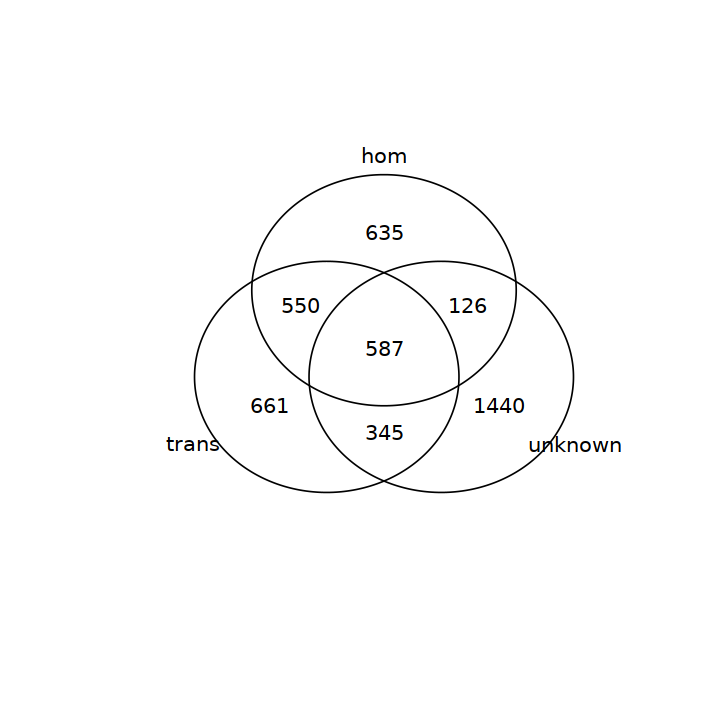

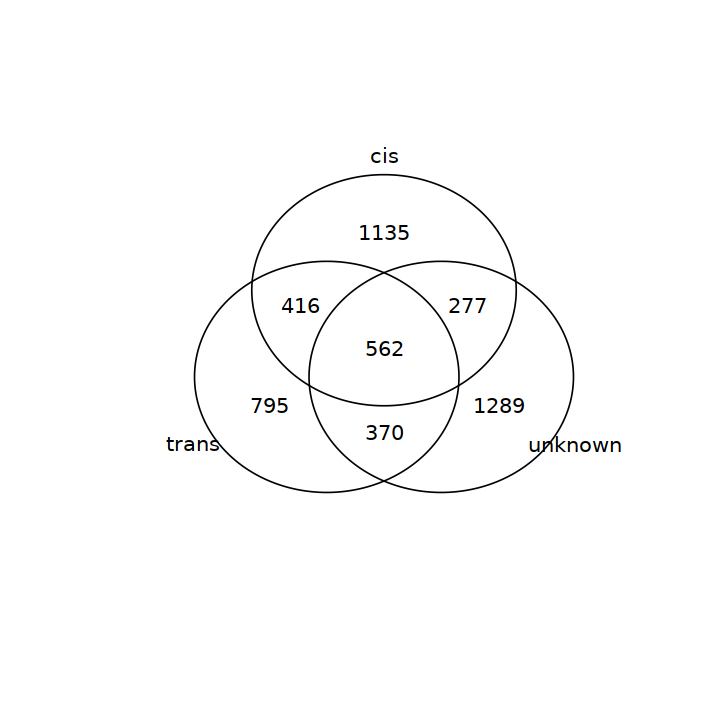

In [78]:
options(repr.plot.width=6, repr.plot.height=6)
#d_genes_venn <- d_genes[d_genes$knockout >= 1]
#g_chet_trans <- unique(d_genes_venn$gene_id[d_genes_venn$chet_trans > 0])
#g_chet_cis <- unique(d_genes_venn$gene_id[d_genes_venn$chet_cis > 0])
#g_chet_unknown <- unique(d_genes_venn$gene_id[d_genes_venn$chet_unknown > 0])
#g_hom <- unique(d_genes_venn$gene_id[d_genes_venn$hom > 0])

genes_unknown <- unique(d$gene_id[d$knockout == "Possible Compound heterozygote"])
genes_trans <- unique(d$gene_id[d$knockout == "Compound heterozygote"])
genes_hom <- unique(d$gene_id[d$knockout == "Homozygote"])
genes_cis <- unique(d$gene_id[d$knockout == "Compound heterozygote (cis)"])

venn(
    list(
        trans=genes_trans,
        unknown=genes_unknown,
        hom=genes_hom
    )
)

venn(
    list(
        trans=genes_trans,
        unknown=genes_unknown,
        cis=genes_cis
    )
)

In [76]:
sum(genes_cis %in% genes_unknown)
sum(genes_unknown %in% genes_cis)

[1] 839

[1] 839

#### Geneset plotting

In [111]:
d <- d[d$knockout != "Heterozygote", ]

In [112]:
# new nice labels and order for levels
mapping <- c(
    'Homozygote' = 'Homozygote',
    "Compound heterozygote" = "Compound heterozygote (Trans)",
    'Possible Compound heterozygote' = "Compound heterozygote (Unknown)",
    "Compound heterozygote (cis)" = "Compound heterozygote (Cis)"
)

In [113]:
# setup color scale
my_colors <- c("#00AEEF", "#009444", "#8DC63F", "#BCBEC0")
names(my_colors) <- mapping
fill_scale <- scale_fill_manual(name = "legend", values = my_colors)
color_scale <- scale_color_manual(name = "legend", values = my_colors)



In [114]:
# add position
d$pos <- ensembl_to_pos[d$gene_id]

In [115]:
table(d$knockout)


         Compound heterozygote    Compound heterozygote (cis) 
                         11955                          61594 
                    Homozygote Possible Compound heterozygote 
                         15001                           3835 

In [116]:
result <- aggregate(s ~ knockout  + chr, data = d, FUN = length)
result$chr <- factor(result$chr, levels = paste0("chr",1:22))
result$knockout <- mapping[result$knockout]
result$knockout <- factor(result$knockout, levels = mapping)

In [117]:
table(result$knockout)


                     Homozygote   Compound heterozygote (Trans) 
                             22                              22 
Compound heterozygote (Unknown)     Compound heterozygote (Cis) 
                             22                              22 

In [118]:
m <- data.table(result)


get_col_subset <- function(m, name, newname){
    ch_cis <- m[m$knockout == name,]
    colnames(ch_cis)[3] <- newname
    ch_cis$knockout <- NULL
    return(ch_cis)
}

#mrg <- merge(get_col_subset(m, "Compound heterozygote (Cis)", "chet_cis"), m, by = "chr")
#mrg <- mrg[mrg$knockout != "Compound heterozygote (Cis)",]
mrg <- merge(get_col_subset(m, "Compound heterozygote (Cis)", "chet_cis"), m, by = "chr")
mrg <- mrg[mrg$knockout != "Compound heterozygote (Cis)",]
head(mrg)
#m <- Reduce(merge,list(
#    get_col_subset(m, "Compound heterozygote (Cis)", "chet_cis"),
#    get_col_subset(m, "Compound heterozygote (Trans)", "chet_trans"),
#    get_col_subset(m, "Homozygote", "homs")
#))


chr,chet_cis,knockout,s
<fct>,<int>,<fct>,<int>
chr1,6059,Compound heterozygote (Trans),1597
chr1,6059,Homozygote,2033
chr1,6059,Compound heterozygote (Unknown),389
chr2,6096,Compound heterozygote (Trans),1112
chr2,6096,Homozygote,811
chr2,6096,Compound heterozygote (Unknown),381


In [119]:
#chr_lengths_38 <- c(248956422, 242193529, 198295559,190214555,181538259,170805979,159345973,
#    145138636,138394717,133797422,135086622,133275309,114364328,107043718,101991189,90338345,
#    83257441,80373285,58617616,64444167,46709983,50818468,156040895)
#names(chr_lengths_38) <- paste0("chr",c(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23))
#mrg$len <- chr_lengths_38[mrg$chr]

#dt_subset <- dt_variant_category[dt_variant_category$consequence_category %in% c("pLoF","damaging_missense"),]
#dt_subset_total <- dt_subset[,grepl("n_total",colnames(dt_subset)), with = FALSE]
#dt_subset_total 
#dt_total <- cbind(
#    dt_subset[,c(1,2)],
#    dt_subset_total
#)
#dt_total <- dt_total[rowSums(dt_total) > 0,]
#dt_total

In [120]:
#options(repr.plot.width=12, repr.plot.height=7)
#ggplot(mrg, aes(x=len, y=s, color=knockout, label = chr)) +
#    geom_point() +
#    geom_text_repel()

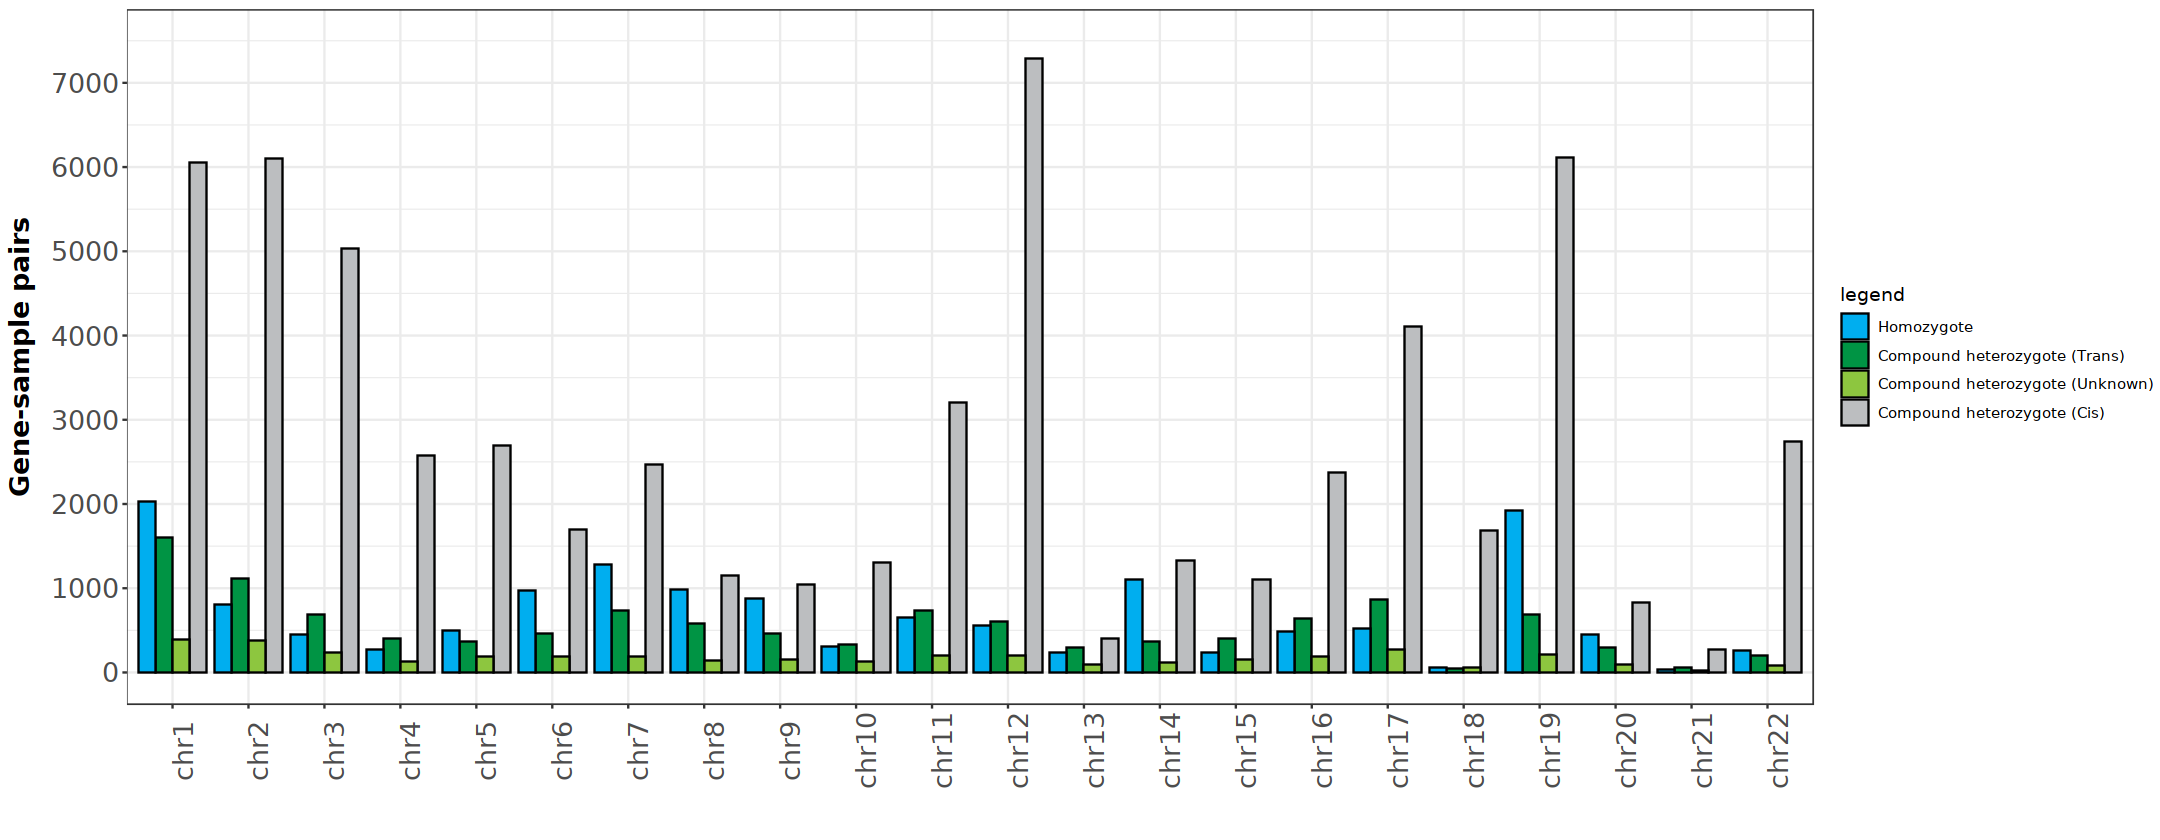

In [121]:
options(repr.plot.width=18, repr.plot.height=7)
ggplot(result, aes(x=chr, y=s, fill=knockout)) +
    geom_bar(stat="identity", position="dodge", color = "black") +
    fill_scale +
    ylab("Gene-sample pairs") +
    xlab("") +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    theme_bw() +
    theme(
        legend.position = "right",
        axis.text=element_text(size=16),
        axis.title=element_text(size=16,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 90, vjust = 1, hjust=0.5)
    ) +
    coord_cartesian(ylim=c(0, 7500))

In [122]:
# get list of recessive, autosomal genes etc
gnomad_genes <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_13_gene_lists.tsv")
gnomad_genes$gene_id <- hgnc_to_ensembl[gnomad_genes$gene]
gnomad_mapping <- gnomad_genes$gene_list
names(gnomad_mapping) <- gnomad_genes$gene_id
d$geneset <- gnomad_mapping[d$gene_id]


In [123]:
autosomes <- paste0("chr",1:22)

In [124]:
gene_df <- aggregate(s ~ geneset + knockout, data = d, FUN = length)
#gene_df$chr <- factor(gene_df$chr, levels = autosomes)
#gene_df <- gene_df[!grepl("cis", gene_df$knockout),]
gene_df$knockout <- mapping[gene_df$knockout]

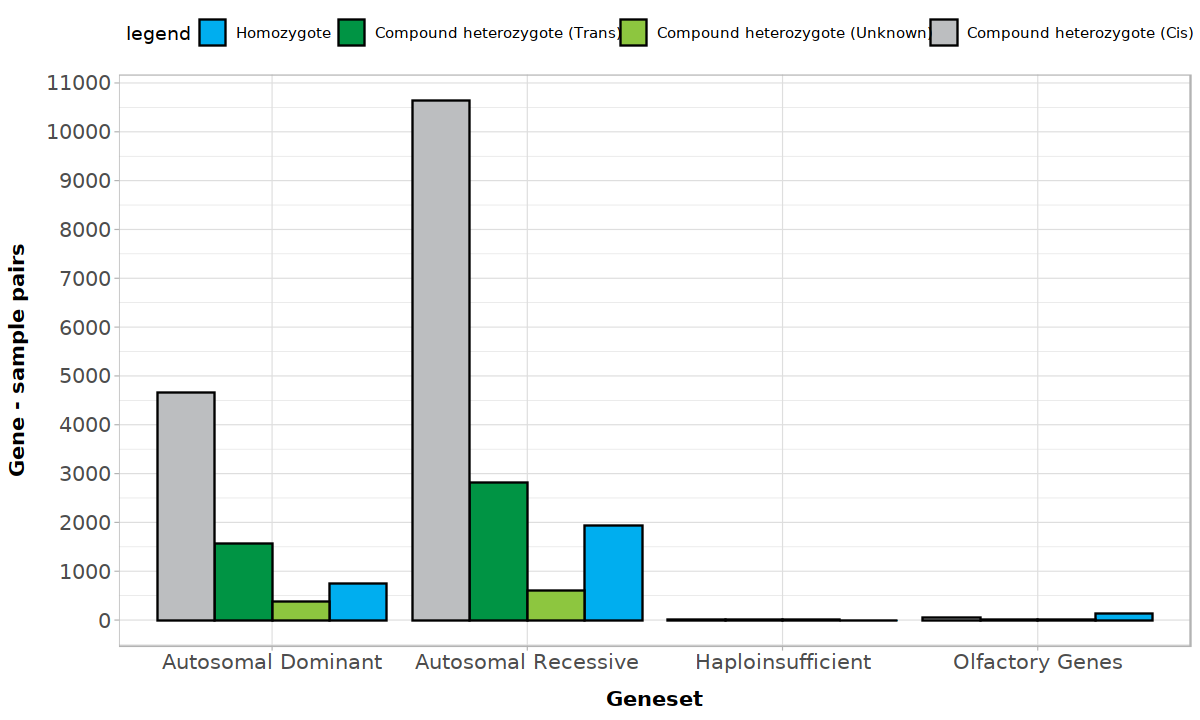

In [125]:
options(repr.plot.width=10, repr.plot.height=6)
ggplot(gene_df, aes(x=geneset, y=s, fill=knockout)) +
    geom_bar(stat="identity", position = position_dodge(), color = 'black') +
    fill_scale +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    ylab("Gene - sample pairs") +
    xlab("Geneset") +
    theme_light() +
    theme(
        legend.position = "top",
        axis.text=element_text(size=12),
        axis.title=element_text(size=12,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5)
    ) #+
    #coord_cartesian(ylim=c(0,10000))
    
    

In [126]:
geneset_count <- data.frame(table(gnomad_genes$gene_list))
colnames(geneset_count) <- c("geneset", "geneset_count")
geneset_count

geneset,geneset_count
<fct>,<int>
Autosomal Dominant,708
Autosomal Recessive,1178
Haploinsufficient,189
Olfactory Genes,356


In [127]:
gene_df <- d[,c("geneset", "gene_id", "knockout")]
gene_df <- gene_df[!is.na(gene_df$geneset),]
gene_df <- gene_df[!duplicated(gene_df),]
gene_table <- data.frame(table(gene_df$geneset, gene_df$knockout))
colnames(gene_table) <- c("geneset","knockout","count")

In [128]:
mrg <- merge(gene_table, geneset_count, all.x = TRUE)
mrg$pct_of_geneset <- round(100*(mrg$count / mrg$geneset_count), 1)
mrg$knockout <- mapping[mrg$knockout]

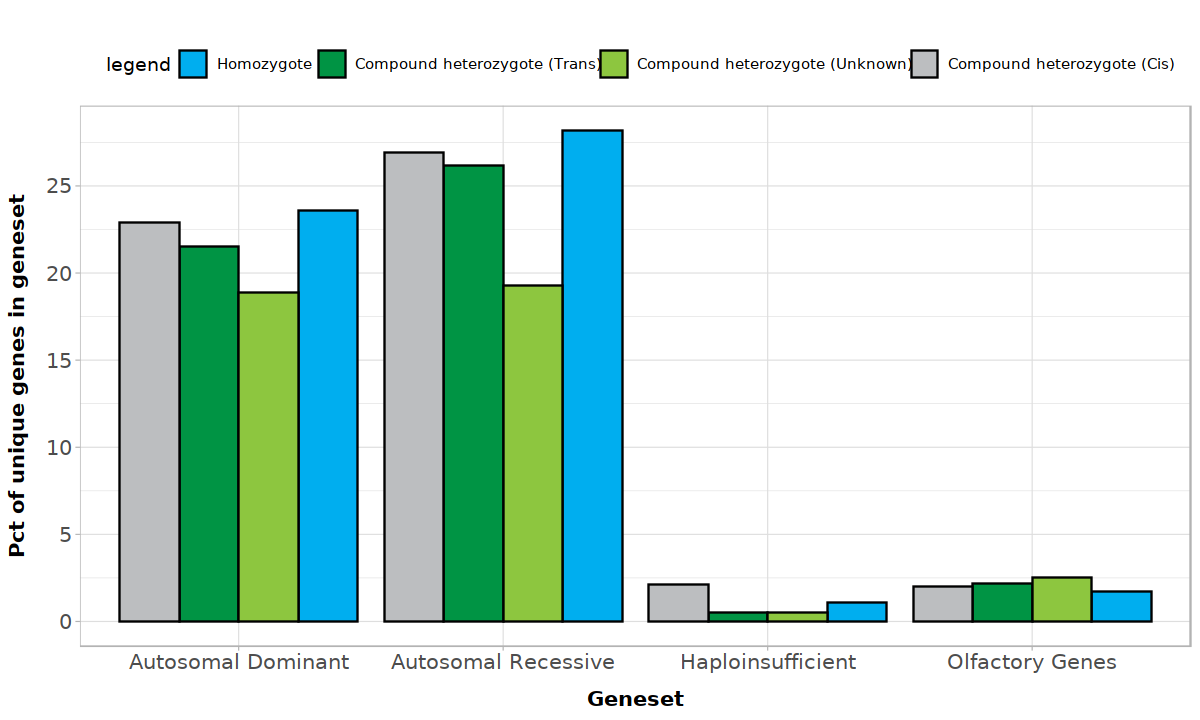

In [129]:
options(repr.plot.width=10, repr.plot.height=6)
ggplot(mrg, aes(x=geneset, y=pct_of_geneset, fill = knockout)) +
    geom_bar(stat="identity", position = position_dodge(), color = 'black') +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    fill_scale +
    xlab("Geneset") +
    ylab("Pct of unique genes in geneset") +
    ggtitle("") +
    theme_light() +
    theme(
        legend.position = "top",
        axis.text=element_text(size=12),
        axis.title=element_text(size=12,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5)
    )


# Gene knockout counts table

In [130]:
# a function to find the samples with at least one knockout in gene and fraction of total samples
get_sample_ko_table <- function(dt, categories, geneset, total_samples, knockout_annotation){

    stopifnot(!is.null(geneset))
    stopifnot(total_samples > 100)
    stopifnot(length(knockout_annotation) > 1)
    
    # get individual categories
    cat_lst <- lapply(categories, function(category){
        carry_ge_one_ko <- dt[dt$knockout == category,]
        carry_ge_one_geneset_ko <- dt[dt$knockout == category & dt$gene_id %in% geneset, ]
        n_all <- length(unique(carry_ge_one_ko$s))
        n_geneset <- length(unique(carry_ge_one_geneset_ko$s))
        res <- data.frame(
            category = category,
            n_all = n_all,
            n_pct_all = round( (n_all / total_samples) * 100, 2),
            n_geneset = n_geneset,
            n_pct_geneset = round( (n_geneset / total_samples) * 100, 2)
        ) 
        return(res)
    })

    cat_dt <- do.call(rbind, cat_lst)

    # go over combined category and get count
    carry_ge_one_ko <- dt[dt$knockout %in% knockout_annotation]
    carry_ge_one_geneset_ko <- dt[dt$knockout %in% knockout_annotation & dt$gene_id %in% geneset ]
    n_all <- length(unique(carry_ge_one_ko$s))
    n_geneset <- length(unique(carry_ge_one_geneset_ko$s))
    res <- data.frame(
            category = "Knockout",
            n_all = n_all,
            n_pct_all = round( (n_all / total_samples) * 100, 2),
            n_geneset = n_geneset,
            n_pct_geneset = round( (n_geneset / total_samples) * 100, 2)
    ) 

    final <- rbind(cat_dt, res)
    return(final)
}



In [131]:
# new nice labels and order for levels
mapping <- c(
    "Heterozygote" = "Heterozygote",
    'Homozygote' = 'Homozygote',
    "Compound heterozygote" = "Compound heterozygote (Trans)",
    'Possible Compound heterozygote' = "Compound heterozygote (Unknown)",
    "Compound heterozygote (cis)" = "Compound heterozygote (Cis)",
    "Knockout" = "Knockout"
)

In [132]:
# mapping bridge
bridge <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/220524_hgnc_ensg_enst_chr_pos.txt.gz")
hgnc_to_ensembl <- bridge$ensembl_gene_id
names(hgnc_to_ensembl) <- bridge$hgnc_symbol

# omim genes
omim <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/omim//211103_morbidmap_by_gene.txt")
omim_hgnc <- unique(omim$gene)
omim_ensgid <- unique(omim$ensgid)

In [159]:
autosomes = 1:22
lst_plof_missense <- lapply(autosomes, function(chr){
    path <- paste0("data/knockouts/alt//ukb_eur_wes_200k_chrCHR_maf0to5e-2_pLoF_damaging_missense_all.tsv.gz")
    path <- gsub("CHR",chr, path)
    d <- fread(path)
    return(d)
})

dt_plof_missense <- setDT(do.call(rbind, lst_plof_missense))
# total samples in data
total_samples = 176915
# categories to be assessed
categories <- unique(dt_plof_missense$knockout)
# what constitutes a full knockout?
knockout_annotation <- c("Compound heterozygote","Homozygote")
d_plof_missense <- get_sample_ko_table(dt_plof_missense, categories, omim_ensgid, total_samples, knockout_annotation)

In [166]:
length(unique(dt_plof_missense[dt_plof_missense$pKO == 1]$gene_id))

[1] 2904

In [154]:
autosomes = 1:22
lst_plof <- lapply(autosomes, function(chr){
    path <- paste0("data/knockouts/alt//ukb_eur_wes_200k_chrCHR_maf0to5e-2_pLoF_all.tsv.gz")
    path <- gsub("CHR",chr, path)
    d <- fread(path)
    return(d)
})

dt_plof <- setDT(do.call(rbind, lst_plof))
# total samples in data
total_samples = 176915
# categories to be assessed
categories <- unique(dt_plof$knockout)
# what constitutes a full knockout?
knockout_annotation <- c("Compound heterozygote","Homozygote")
d_plof <- get_sample_ko_table(dt_plof, categories, omim_ensgid, total_samples, knockout_annotation)

In [135]:
d_plof$category <- mapping[d_plof$category]
d_plof_missense$category <- mapping[d_plof_missense$category]
d_plof_missense <- d_plof_missense[match(d_plof$category, d_plof_missense$category),]

In [136]:
stopifnot(d_plof_missense$category == d_plof$category)

In [137]:
tab <- data.frame(
    category = d_plof$category,
    plof_n_all = paste0(d_plof$n_all, " (", d_plof$n_pct_all,"%)"),
    plof_n_omim = paste0(d_plof$n_geneset, " (", d_plof$n_pct_geneset,"%)"),
    plof_missense_n_all = paste0(d_plof_missense$n_all, " (", d_plof_missense$n_pct_all,"%)"),
    plof_missense_n_omim = paste0(d_plof_missense$n_geneset, " (", d_plof_missense$n_pct_geneset,"%)")

)
tab <- tab[c(1,2,5,3,4,6),]
rownames(tab) <- NULL
tab

category,plof_n_all,plof_n_omim,plof_missense_n_all,plof_missense_n_omim
<chr>,<chr>,<chr>,<chr>,<chr>
Heterozygote,176915 (100%),164959 (93.24%),176915 (100%),176913 (100%)
Compound heterozygote (Cis),31588 (17.85%),6835 (3.86%),51582 (29.16%),18053 (10.2%)
Compound heterozygote (Trans),1525 (0.86%),239 (0.14%),11514 (6.51%),5662 (3.2%)
Compound heterozygote (Unknown),1364 (0.77%),374 (0.21%),3754 (2.12%),1604 (0.91%)
Homozygote,8363 (4.73%),796 (0.45%),14163 (8.01%),3505 (1.98%)
Knockout,9830 (5.56%),1035 (0.59%),24750 (13.99%),9055 (5.12%)


# Unique genes affected

In [167]:
check_geneset <- function(dt, geneset, to_real_table = TRUE){
    
    df <- dt
    df$geneset <- df$gene_id %in% geneset
    gene_df <- aggregate(gene_id ~ geneset + knockout, data = df, FUN = length)
    gene_df <- gene_df[gene_df$geneset == TRUE,]
    colnames(gene_df)[3] <- "n"
    gene_df$geneset_size <- length(unique(geneset))
    gene_df$pct_of_geneset <- round((gene_df$n / gene_df$geneset_size) * 100,1)
    gene_df$geneset <- NULL
    rownames(gene_df) <- NULL
    
    if (to_real_table){
        gene_df$geneset_size <- NULL
        gene_df$n <- paste0(gene_df$n, ' (', gene_df$pct_of_geneset, '%)')
        gene_df$pct_of_geneset <- NULL
    }
    
    return(gene_df)
}



In [176]:
dt <- dt_plof_missense
head(dt)

gene_id,s,gts,varid,hom_alt_n,phased.a1,phased.a2,unphased.n,pKO,knockout
<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<chr>
ENSG00000000457,1008716,"[""0|1""]","[""chr1:169876054:A:G""]",0,0,1,0,0,Heterozygote
ENSG00000000457,1016311,"[""0|1""]","[""chr1:169868968:G:A""]",0,0,1,0,0,Heterozygote
ENSG00000000457,1017844,"[""0|1""]","[""chr1:169876054:A:G""]",0,0,1,0,0,Heterozygote
ENSG00000000457,1018695,"[""0|1""]","[""chr1:169876054:A:G""]",0,0,1,0,0,Heterozygote
ENSG00000000457,1020249,"[""0|1""]","[""chr1:169876054:A:G""]",0,0,1,0,0,Heterozygote
ENSG00000000457,1025619,"[""1|0""]","[""chr1:169876054:A:G""]",0,1,0,0,0,Heterozygote


In [178]:
length(unique(dt[dt$pKO == 1]$gene_id))

[1] 2904

In [197]:
dt <- dt_plof #dt_plof_missense
dt <- dt[,c("gene_id", "knockout",'pKO')]
dt <- dt[!duplicated(dt),]
ndt <- dt[(dt$pKO == 1)]
ndt$knockout <- "Knockout"
ndt <- ndt[!duplicated(ndt$gene_id),]
dt <- rbind(dt, ndt)

# protein coding
coding <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart//protein_coding_genes.tsv") 

# omim genes
omim <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/omim//211103_morbidmap_by_gene.txt")
omim_hgnc <- unique(omim$gene)
omim_ensgid <- unique(omim$ensgid)

# gtex brain
gtex <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gtex/GTEx.tstat.tsv")
gtex_brain <- gtex$ENSGID[gtex$Brain_Cortex >= quantile(gtex$Brain_Cortex, probs = 0.9)]

# gnomad
gnomad_genes <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/gnomad/karczewski2020/supplementary_dataset_13_gene_lists.tsv")
gnomad_genes$gene_id <- hgnc_to_ensembl[gnomad_genes$gene]
genes_auto_dom <- gnomad_genes$gene_id[gnomad_genes$gene_list %in% "Autosomal Dominant"]
genes_auto_rec <- gnomad_genes$gene_id[gnomad_genes$gene_list %in% "Autosomal Recessive"]
genes_olf <- gnomad_genes$gene_id[gnomad_genes$gene_list %in% "Olfactory Genes"]
genes_hap <- gnomad_genes$gene_id[gnomad_genes$gene_list %in% "Haploinsufficient"]

 
genes <- check_geneset(dt, unique(dt$gene_id))
colnames(genes)[2] <- "Genes n (% of geneset)"
protein_coding <- check_geneset(dt, unique(coding$ensembl_gene_id))
colnames(protein_coding)[2] <- "Protein Coding n (% of geneset)"
omim <- check_geneset(dt, omim_ensgid)
colnames(omim)[2] <- "OMIM n (% of geneset)"
dom <- check_geneset(dt, genes_auto_dom)
colnames(dom)[2] <- "Autosomal Dominant n (% of geneset)"
rec <- check_geneset(dt, genes_auto_rec)
colnames(rec)[2] <- "Autosomal Recessive n (% of geneset)"
olf <- check_geneset(dt, genes_olf)
colnames(olf)[2] <- "Olfactory Genes n (% of geneset)"
hap <- check_geneset(dt, genes_hap)
colnames(hap)[2] <- "Haploinsufficient n (% of geneset)"

final <- Reduce(merge, list(genes, protein_coding, omim, dom, rec, olf))
final$knockout <- mapping[final$knockout]
final <- final[c(3,2,1,6,4,5),]
rownames(final) <- NULL
final

knockout,Genes n (% of geneset),Protein Coding n (% of geneset),OMIM n (% of geneset),Autosomal Dominant n (% of geneset),Autosomal Recessive n (% of geneset),Olfactory Genes n (% of geneset)
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Heterozygote,15883 (99.6%),15605 (71.2%),3617 (83.6%),572 (81.7%),1099 (95.3%),162 (45.8%)
Compound heterozygote (Cis),1346 (8.4%),1329 (6.1%),361 (8.3%),49 (7%),125 (10.8%),9 (2.5%)
Compound heterozygote (Trans),542 (3.4%),533 (2.4%),102 (2.4%),17 (2.4%),33 (2.9%),6 (1.7%)
Compound heterozygote (Unknown),1265 (7.9%),1253 (5.7%),342 (7.9%),43 (6.1%),120 (10.4%),6 (1.7%)
Homozygote,759 (4.8%),744 (3.4%),113 (2.6%),15 (2.1%),43 (3.7%),9 (2.5%)
Knockout,1014 (6.4%),996 (4.5%),172 (4%),24 (3.4%),64 (5.6%),13 (3.7%)


In [140]:
0.0000000000150776

[1] 1.50776e-11

# Genes affected by knockout count

In [141]:
#autosomes = 1:22
#lst <- lapply(autosomes, function(chr){
#    path <- paste0("data/knockouts/alt//ukb_eur_wes_200k_chrCHR_maf0to5e-2_pLoF_damaging_missense_all.tsv.gz")
#    path <- gsub("CHR",chr, path)
#    d <- fread(path)
#    return(d)
#})
#
#dt <- setDT(do.call(rbind, lst))
## total samples in data
#total_samples = 176915
## categories to be assessed
#categories <- unique(dt$knockout)
## what constitutes a full knockout?
#knockout_annotation <- c("Compound heterozygote","Homozygote")

In [142]:
#dt_gene <- dt[dt$knockout %in% knockout_annotation & dt$pKO == 1,]
#dt_gene <- as.data.table(table(dt_gene$gene_id, dt_gene$knockout))
#colnames(dt_gene) <- c("gene","knockout","count")
#dt_gene <- dcast(gene~knockout, value.var = "count", data = dt_gene)
#dt_gene$knockout <- dt_gene$`Compound heterozygote` + dt_gene$Homozygote
#dt_gene$hgnc_symbol <- ensembl_to_hgnc[dt_gene$gene]
#dt_gene <- dt_gene[,c(1,5,2,3,4)]
#dt_gene <- dt_gene[rev(order(dt_gene$knockout)),]

In [143]:
#sum(dt_gene$knockout > 1); nrow(dt_gene)

In [148]:
d <- fread("data/post_hoc/results/pLoF_damaging_missense_maf0to5e-2_knockouts_by_genes.txt.gz")

In [149]:
d$knockouts <- d$`CHET-TRANS` + d$HOM
d <- d[d$knockouts > 0,]
d$hgnc_symbol <- ensembl_to_hgnc[d$ensembl_gene_id]
d <- d[rev(order(d$knockout)),]

In [151]:
options(repr.matrix.max.rows=100, repr.matrix.max.cols=50)
nrow(d)
d

[1] 2904

hgnc_symbol,ensembl_gene_id,CHET-CIS,CHET-TRANS,CHET-UNKNOWN,HET,HOM,knockouts
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
PKHD1L1,ENSG00000205038,98,322,17,21023,398,720
FMO2,ENSG00000094963,1,168,2,18265,353,521
GMPR2,ENSG00000100938,3,17,6,16587,424,441
UBE2W,ENSG00000104343,0,1,2,15740,417,418
ANKLE1,ENSG00000160117,15,15,0,16384,402,417
ATP6V0A4,ENSG00000105929,22,25,7,16425,356,381
AMPD1,ENSG00000116748,16,115,10,14288,210,325
ETFB,ENSG00000105379,29,4,2,14371,320,324
MICA,ENSG00000204520,9,29,0,14628,293,322


In [ ]:
d <- fread("data/post_hoc/results/")

In [125]:
d <- fread("data/post_hoc/results/pLoF_damaging_missense_maf0to5e-2_knockouts_by_phenotypes.txt.gz")
d <- d[!grepl("primary_care",d$phenotype),]
d$knockout <- d$`CHET-TRANS` + d$HOM
d <- d[rev(order(d$knockout)),]
d

phenotype,CHET-CIS,CHET-TRANS,CHET-UNKNOWN,HET,HOM,phenos_na,cases_all,controls_all,cases_nfe,controls_nfe,knockout
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
genetic.eur.no.fin.oct2021,61489,11946,3831,6553880,14977,0,176594,0,176594,0,26923
genetic.eur.oct2021,61489,11946,3831,6553880,14977,0,176594,0,176594,0,26923
CAD_combined,6980,1350,407,734727,1630,30,19778,156786,19778,156786,2980
RF_combined,3991,838,268,421223,962,0,11331,165263,11331,165263,1800
DEP_combined,3529,709,229,381260,873,0,10252,166342,10252,166342,1582
COPD_combined,3051,637,165,334566,730,0,8993,167601,8993,167601,1367
HEM_combined,2935,598,166,318621,751,0,8580,168014,8580,168014,1349
BC_combined,2848,566,175,298954,701,0,8035,168559,8035,168559,1267
RF_acute_combined,2319,508,156,244664,577,4753,6578,165263,6578,165263,1085


# Fraction of variant consequence by Compound Het

In [416]:
d <- fread( paste0("data/knockouts/tables/pLoF_damaging_missense_full_chr21.txt.gz"))
d <- d[d$pKO > 0.5]
d$knockout <- mapping[d$knockout]

In [417]:
head(d)

gene_id,s,gts,varid,hom_alt_n,phased.a1,phased.a2,unphased.n,pKO,knockout,⋯,cadd_phred,most_severe_csqs,AF,AC,AN,gene_symbol,exon,codon,amino_acids,chr
<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
ENSG00000141956,2693945,"0|1, 1|0","chr21:41861739:TG:T, chr21:41878845:C:CA",0,1,1,0,1,Compound heterozygote (Trans),⋯,"NA, NA, NA, NA","frameshift_variant, frameshift_variant, upstream_gene_variant, upstream_gene_variant","2.5436e-05, 3.6741e-05, 3.6741e-05, 3.6741e-05","2.5436e-05, 3.6741e-05, 3.6741e-05, 3.6741e-05","353830, 353830, 353830, 353830","PRDM15, PRDM15, AP001619.1, RF00334","7/31, 3/31, NA, NA","ttC/tt, cgg/cTgg, NA, NA","F/X, R/LX, NA, NA",21
ENSG00000141959,1609598,"1|0, 0|1","chr21:44316307:G:A, chr21:44316316:A:C",0,1,1,0,1,Compound heterozygote (Trans),⋯,"24.9, 25.1","missense_variant, missense_variant","0.00011022, 9.0439e-05","0.00011022, 9.0439e-05","353830, 353830","PFKL, PFKL","8/22, 8/22","Ggg/Agg, Atc/Ctc","G/R, I/L",21
ENSG00000141959,1799167,1|1,chr21:44325182:C:A,1,0,0,0,1,Homozygote,⋯,"25.9, NA, NA","missense_variant, downstream_gene_variant, downstream_gene_variant","0.0018512, 0.0018512, 0.0018512","0.0018512, 0.0018512, 0.0018512","353830, 353830, 353830","PFKL, AP001062.3, CFAP410","19/22, NA, NA","aCg/aAg, NA, NA","T/K, NA, NA",21
ENSG00000141959,2657302,"1|0, 0|1","chr21:44313116:T:C, chr21:44316307:G:A",0,1,1,0,1,Compound heterozygote (Trans),⋯,"27.3, 24.9","missense_variant, missense_variant","0.00029393, 0.00011022","0.00029393, 0.00011022","353830, 353830","PFKL, PFKL","5/22, 8/22","aTc/aCc, Ggg/Agg","I/T, G/R",21
ENSG00000141959,4327625,"0|1, 1|0","chr21:44316290:G:T, chr21:44316307:G:A",0,1,1,0,1,Compound heterozygote (Trans),⋯,"25, 24.9","missense_variant, missense_variant","5.6524e-06, 0.00011022","5.6524e-06, 0.00011022","353830, 353830","PFKL, PFKL","8/22, 8/22","gGt/gTt, Ggg/Agg","G/V, G/R",21
ENSG00000142156,1516508,"0|1, 1|0","chr21:45984391:T:C, chr21:45999190:A:C",0,1,1,0,1,Compound heterozygote (Trans),⋯,"25.3, 27","missense_variant, missense_variant","0.0016816, 0.00040415","0.0016816, 0.00040415","353830, 353830","COL6A1, COL6A1","3/35, 26/35","gTg/gCg, aAg/aCg","V/A, K/T",21


In [419]:
colnames(d)

[1] "gene_id"          "s"                "gts"              "varid"           
 [5] "hom_alt_n"        "phased.a1"        "phased.a2"        "unphased.n"      
 [9] "pKO"              "knockout"         "revel_score"      "cadd_phred"      
[13] "most_severe_csqs" "AF"               "AC"               "AN"              
[17] "gene_symbol"      "exon"             "codon"            "amino_acids"     
[21] "chr"

In [420]:
print(d[1,])

           gene_id       s      gts                                    varid
1: ENSG00000141956 2693945 0|1, 1|0 chr21:41861739:TG:T, chr21:41878845:C:CA
   hom_alt_n phased.a1 phased.a2 unphased.n pKO                      knockout
1:         0         1         1          0   1 Compound heterozygote (Trans)
      revel_score     cadd_phred
1: NA, NA, NA, NA NA, NA, NA, NA
                                                                       most_severe_csqs
1: frameshift_variant, frameshift_variant, upstream_gene_variant, upstream_gene_variant
                                               AF
1: 2.5436e-05, 3.6741e-05, 3.6741e-05, 3.6741e-05
                                               AC
1: 2.5436e-05, 3.6741e-05, 3.6741e-05, 3.6741e-05
                               AN                         gene_symbol
1: 353830, 353830, 353830, 353830 PRDM15, PRDM15, AP001619.1, RF00334
                 exon                    codon       amino_acids chr
1: 7/31, 3/31, NA, NA ttC/tt, cgg/cTgg,

In [421]:
vep <- fread(paste0('data/mt/vep/worst_csq_by_gene_canonical/ukb_eur_wes_union_calls_200k_chr',chr,'.tsv.gz'))

In [422]:
colnames(vep)

[1] "locus"                        "alleles"                     
 [3] "rsid"                         "info.AC"                     
 [5] "info.AF"                      "info.AN"                     
 [7] "MAF"                          "MAC"                         
 [9] "varid"                        "csqs.allele_num"             
[11] "csqs.amino_acids"             "csqs.biotype"                
[13] "csqs.canonical"               "csqs.ccds"                   
[15] "csqs.cdna_start"              "csqs.cdna_end"               
[17] "csqs.cds_end"                 "csqs.cds_start"              
[19] "csqs.codons"                  "csqs.consequence_terms"      
[21] "csqs.distance"                "csqs.domains"                
[23] "csqs.exon"                    "csqs.gene_id"                
[25] "csqs.gene_pheno"              "csqs.gene_symbol"            
[27] "csqs.gene_symbol_source"      "csqs.hgnc_id"                
[29] "csqs.hgvsc"                   "csqs.hgvsp"                  
[31] "csqs.hgvs_offset"             "csqs.impact"                 
[33] "csqs.intron"                  "csqs.lof"                    
[35] "csqs.lof_flags"               "csqs.lof_filter"             
[37] "csqs.lof_info"                "csqs.minimised"              
[39] "csqs.polyphen_prediction"     "csqs.polyphen_score"         
[41] "csqs.protein_end"             "csqs.protein_start"          
[43] "csqs.protein_id"              "csqs.sift_prediction"        
[45] "csqs.strand"                  "csqs.swissprot"              
[47] "csqs.transcript_id"           "csqs.trembl"                 
[49] "csqs.uniparc"                 "csqs.variant_allele"         
[51] "csqs.revel_score"             "csqs.cadd_phred"             
[53] "csqs.most_severe_consequence" "csqs.csq_score"              
[55] "consequence_category"

In [424]:
print(head(vep$consequence_category))

[1] "non_coding" "non_coding" "non_coding" "non_coding" "non_coding"
[6] "non_coding"
